In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [3]:
checker = pd.io.sql.read_sql(
    "SELECT timestamp FROM checker WHERE uid LIKE 'user_%'",
    conn, parse_dates=['timestamp']
)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [4]:
checker['date'] = checker['timestamp'].dt.date
checker['hour'] = checker['timestamp'].dt.hour
checker['day_of_week'] = checker['timestamp'].dt.dayofweek
checker['day_type'] = checker['day_of_week'].apply(lambda x: 'weekend' if x >= 5 else 'working_day')
checker

,timestamp,date,hour,day_of_week,day_type
0,2020-04-17 05:19:02.744528,2020-04-17,5,4,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,5,4,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,5,4,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,5,4,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,5,4,working_day
...,...,...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,20,3,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,20,3,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,20,3,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,20,3,working_day


In [5]:
avg_commits_by_hour = checker.groupby(['date', 'hour', 'day_type']).size().reset_index(name='commits')\
    .groupby(['hour', 'day_type'])['commits'].mean().reset_index()
avg_commits_by_hour

,hour,day_type,commits
0,0,weekend,2.000000
1,0,working_day,3.000000
2,1,weekend,6.000000
3,3,weekend,1.000000
4,3,working_day,2.000000
5,5,weekend,2.000000
6,5,working_day,7.500000
7,6,working_day,1.500000
8,7,weekend,4.000000
9,7,working_day,5.166667


Text(0.5, 0.98, 'Commits per hour')

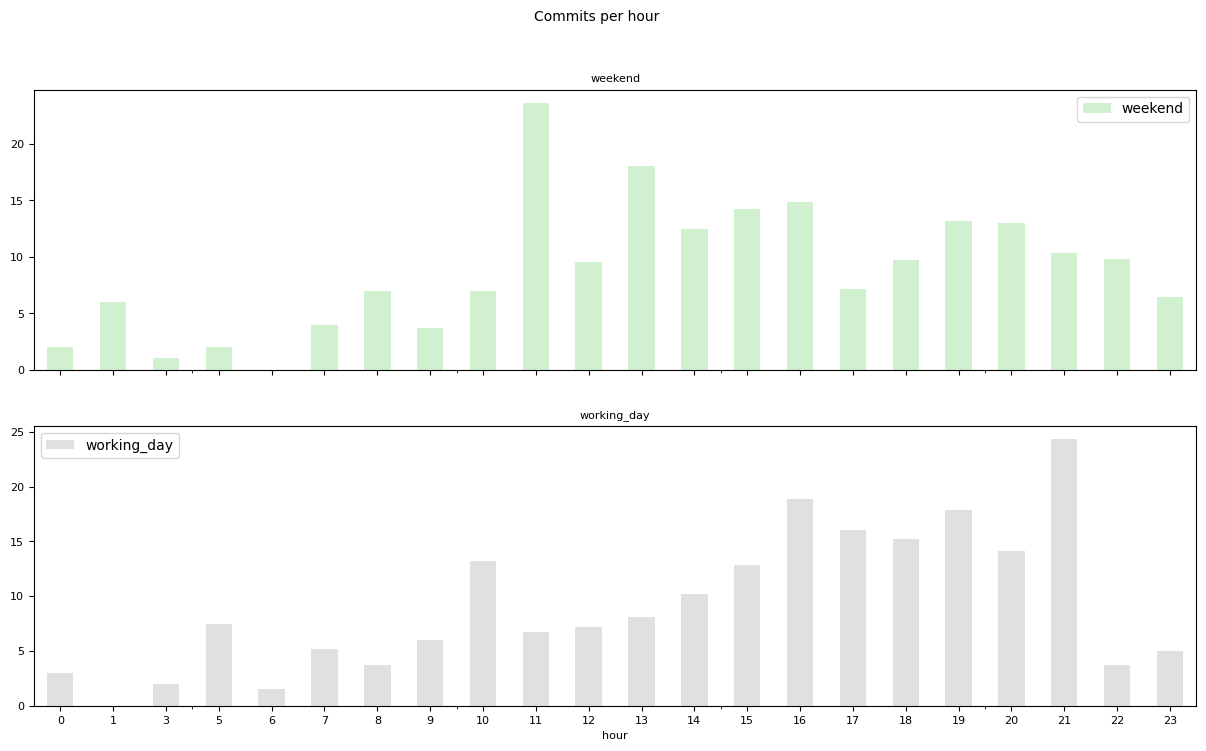

In [6]:
pivot = avg_commits_by_hour.pivot(index='hour', columns='day_type', values='commits')

axes = pivot[['weekend', 'working_day']].plot.bar(
    subplots=True,
    layout=(2, 1),
    figsize=(15, 8),
    fontsize=8,
    color={'weekend': '#D0F0D0', 'working_day': '#E0E0E0'},
    rot=0
)
axes[0][0].set_title('weekend', fontsize=8)
axes[1][0].set_title('working_day', fontsize=8)
axes[1][0].set_xlabel('hour', fontsize=8)
axes[0][0].get_figure().suptitle('Commits per hour', fontsize=10)


In [7]:
conn.close()

Отличается ли динамика в рабочие и выходные дни?

**Ответ:** Да, динамика отличается. Час с наибольшим числом коммитов в будни - **21**, в выходные - **11**.